# RLC Circuit with PID Controller Simulation
Author: Zachary Lee
<hr>

A PID Controller is a feedback control system that continuously measures the difference between where a system is and where it should be, and applies a corrective force to drive the system toward its goal. In this simulation, I will be using a PID Controller to manage the signal from an RLC Circuit. For full derivations of the RLC circuit governing equations, Kirchoff's Loop Laws, and the numerical implementation of the PID control law, see [Physics_Background.md](docs/Physics_Background.md).

In [94]:
# ---------------------------------------------------------
# Imports and Constants Cell
#----------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Simulation Parameters
# ---------------------------------------------------------
dt      = 0.001   # Timestep (s)
t_end   = 5.0     # Simulation duration (s)
t       = np.arange(0, t_end, dt)  # Time array

# ---------------------------------------------------------
# PID Gains
# ---------------------------------------------------------
Kp = 8.0    # Proportional gain
Ki = 5.0    # Integral gain
Kd = 0.1    # Derivative gain

# ---------------------------------------------------------
# Circuit Component Values
# ---------------------------------------------------------
L = 0.1  # Inductor (H)
R = 2.0  # Resistor (Ohm)
C = 0.05 # Capacitor (F)

# ---------------------------------------------------------
# Target Setpoint
# ---------------------------------------------------------
V_target = 5.0    # Target voltage (V)

In [95]:
# ---------------------------------------------------------
# Definition Cell
# ---------------------------------------------------------

# ---------------------------------------------------------
# Initialises RLC component values.
# Note: R and C are scaled from typical values I've worked with to
# produce clearly visible dynamics on a human-readable timescale.
# Everything will reflect real RLC circuit dynamics.
# ---------------------------------------------------------
class RLCCircuit:
    def __init__(self, L=0.1, R=2.0, C=0.05):
        self.L = L
        self.R = R
        self.C = C

    # Computes the time derivatives of charge and current.
    def derivatives(self, q, I, u):
        dqdt = I # Definition of current (change in charge over time).
        dIdt = (u - self.R * I - (1/self.C) * q) / (self.L) # Used the 2nd-order ODE from "Physics_Background.md" to express the change in current in terms of q, I, L, and u.

        return dqdt, dIdt
    

    # Returns the voltage of the capacitor from given charge.
    def capacitor_voltage(self, q):
        return q / self.C

# Computes the PID control signal.
class PIDController:
    def __init__(self, Kp, Ki, Kd, dt):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.integral = 0.0
        self.previous_error = 0.0

    def compute(self, setpoint, measurement):
        error = setpoint - measurement #e(t)
        self.integral += error * self.dt # sum of error over time 
        derivative = (error - self.previous_error) / self.dt # backward finite difference
        u = (self.Kp * error + self.Ki * self.integral + self.Kd * derivative) # control signal
        u = np.clip(u, 0, 50) # clamps the signal to stay withing realistic limits.
        self.previous_error = error # stores the current error
        return u


In [96]:
# ---------------------------------------------------------
# Simulation Cell
# ---------------------------------------------------------

# Create objects
circuit = RLCCircuit(L=L, R=R, C=C)
pid = PIDController(Kp=Kp, Ki=Ki, Kd=Kd, dt=dt)

# ---------------------------------------------------------
# Storage Arrays
# ---------------------------------------------------------
q = np.zeros(len(t)) # Charge (C)
I = np.zeros(len(t)) # Current (A)
Vc = np.zeros(len(t)) # Capacitor Voltage (V)
u = np.zeros(len(t)) # Control Signal (V)
error_log = np.zeros(len(t)) # Error over time.

# ---------------------------------------------------------
# Initial Conditions
# ---------------------------------------------------------
q[0] = 0.0 # No initial charge.
I[0] = 0.0 # No initial current.

# ---------------------------------------------------------
# Simulation Loop
# ---------------------------------------------------------

for i in range(1, len(t)):

    # Current capacitor voltage
    Vc[i-1] = circuit.capacitor_voltage(q[i-1])

    # Error and control signal
    error_log[i-1] = V_target - Vc[i-1]
    u[i] = pid.compute(V_target, Vc[i-1])

    # Derivatives
    dqdt, dIdt = circuit.derivatives(q[i-1], I[i-1], u[i])

    # Euler's method
    q[i] = q[i-1] + dqdt * dt
    I[i] = I[i-1] + dIdt * dt

Vc[-1] = circuit.capacitor_voltage(q[-1])
error_log[-1] = V_target - Vc[-1]


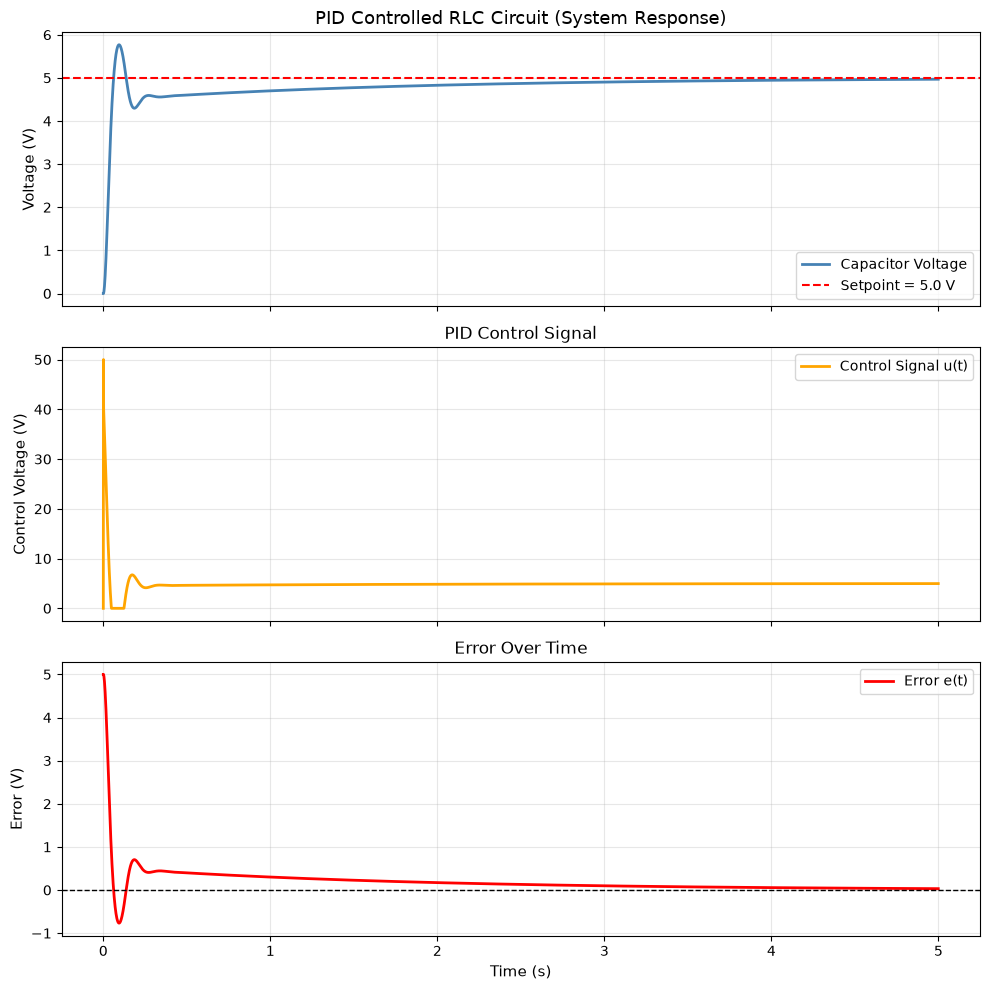

In [97]:
# ---------------------------------------------------------
# Capacitor, Control, Error Plots Cell
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# ---------------------------------------------------------
# Plot 1: Capacitor Voltage
# ---------------------------------------------------------
axes[0].plot(t, Vc, color="steelblue", linewidth=2, label="Capacitor Voltage")
axes[0].axhline(V_target, color="red", linestyle="--", linewidth=1.5, label=f"Setpoint = {V_target} V")
axes[0].set_ylabel("Voltage (V)", fontsize=11)
axes[0].set_title("PID Controlled RLC Circuit (System Response)", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Control Signal
# ---------------------------------------------------------
axes[1].plot(t, u, color="orange", linewidth=2, label="Control Signal u(t)")
axes[1].set_ylabel("Control Voltage (V)", fontsize=11)
axes[1].set_title("PID Control Signal", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 3: Error Signal
# ---------------------------------------------------------
axes[2].plot(t, error_log, color="red", linewidth=2, label="Error e(t)")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Error (V)", fontsize=11)
axes[2].set_xlabel("Time (s)", fontsize=11)
axes[2].set_title("Error Over Time", fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../images/pid_response.png", dpi=150, bbox_inches="tight")
plt.show()

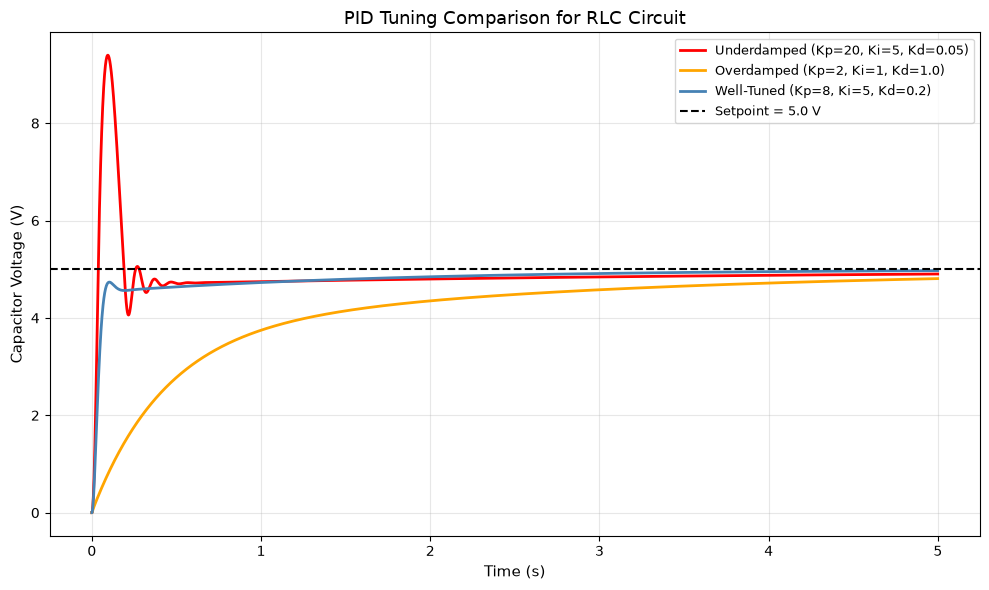

In [98]:
# ---------------------------------------------------------
# Tuning Comparison Plot
# ---------------------------------------------------------

scenarios = {"Underdamped (Kp=20, Ki=5, Kd=0.05)": {"Kp": 20.0, "Ki": 5.0, "Kd": 0.05},
             "Overdamped (Kp=2, Ki=1, Kd=1.0)": {"Kp": 2.0, "Ki": 1.0, "Kd": 1.0},
             "Well-Tuned (Kp=8, Ki=5, Kd=0.2) ": {"Kp": 8.0, "Ki": 5.0, "Kd": 0.2},
}

colors = ["red", "orange", "steelblue"]

fig, ax = plt.subplots(figsize=(10,6))

for (label, gains), color in zip(scenarios.items(), colors):

    # Create PID with scenario gains
    pid_comp = PIDController(Kp=gains["Kp"], Ki=gains["Ki"], Kd=gains["Kd"], dt=dt)

    # Storage
    q_comp = np.zeros(len(t))
    I_comp = np.zeros(len(t))
    Vc_comp = np.zeros(len(t))
    u_comp = np.zeros(len(t))

    # Initial Conditions
    q_comp[0] = 0.0
    I_comp[0] = 0.0

    # Simulation Loop
    for i in range(1, len(t)):
        Vc_comp[i-1] = circuit.capacitor_voltage(q_comp[i-1])
        u_comp[i] = pid_comp.compute(V_target, Vc_comp[i-1])
        u_comp[i] = np.clip(u_comp[i], 0, 50)

        dqdt, dIdt = circuit.derivatives(q_comp[i-1], I_comp[i-1], u_comp[i])

        q_comp[i] = q_comp[i-1] + dqdt * dt
        I_comp[i] = I_comp[i-1] + dIdt * dt

    Vc_comp[-1] = circuit.capacitor_voltage(q_comp[-1])

    ax.plot(t, Vc_comp, color=color, linewidth=2, label=label)

ax.axhline(V_target, color="black", linestyle="--", linewidth=1.5, label=f"Setpoint = {V_target} V")
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Capacitor Voltage (V)", fontsize=11)
ax.set_title("PID Tuning Comparison for RLC Circuit", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../images/pid_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [99]:
print(f"Number of scenarios: {len(Vc_results)}")
print(f"Number of equilibrium values: {len(equilibrium_values)}")
print(f"Equilibrium values: {equilibrium_values}")

Number of scenarios: 3
Number of equilibrium values: 3
Equilibrium values: [7826, 8470, 3998]


[7826, 8470, 3998]
Animation saved to ../images/pid_animation.gif


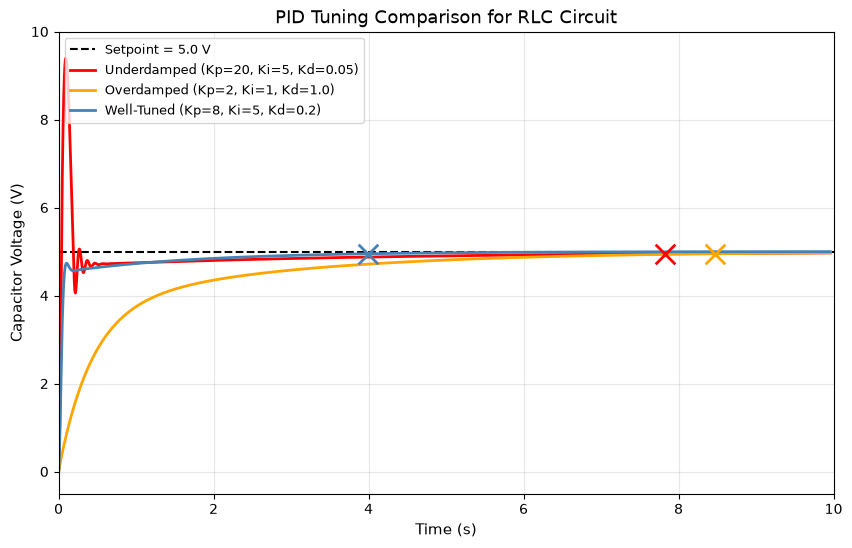

In [100]:
# ---------------------------------------------------------
# Animated PID Tuning Comparison Plot
# ---------------------------------------------------------
import matplotlib.animation as animation

t_end_anim = 10.0
t_anim = np.arange(0, t_end_anim, dt)

# Pre-compute all three scenarios
scenarios_anim = {
    "Underdamped (Kp=20, Ki=5, Kd=0.05)":  {"Kp": 20.0, "Ki": 5.0, "Kd": 0.05},
    "Overdamped (Kp=2, Ki=1, Kd=1.0)":     {"Kp": 2.0,  "Ki": 1.0, "Kd": 1.0},
    "Well-Tuned (Kp=8, Ki=5, Kd=0.2)":     {"Kp": 8.0,  "Ki": 5.0, "Kd": 0.2},
}

colors_anim  = ["red", "orange", "steelblue"]
Vc_results   = []

for gains in scenarios_anim.values():
    pid_a   = PIDController(Kp=gains["Kp"], Ki=gains["Ki"], Kd=gains["Kd"], dt=dt)
    q_a     = np.zeros(len(t_anim))
    I_a     = np.zeros(len(t_anim))
    Vc_a    = np.zeros(len(t_anim))
    u_a     = np.zeros(len(t_anim))

    for i in range(1, len(t_anim)):
        Vc_a[i-1] = circuit.capacitor_voltage(q_a[i-1])
        u_a[i]    = np.clip(pid_a.compute(V_target, Vc_a[i-1]), 0, 50)
        dqdt, dIdt = circuit.derivatives(q_a[i-1], I_a[i-1], u_a[i])
        q_a[i]    = q_a[i-1] + dqdt * dt
        I_a[i]    = I_a[i-1] + dIdt * dt

    Vc_a[-1] = circuit.capacitor_voltage(q_a[-1])
    Vc_results.append(Vc_a)

# ---------------------------------------------------------
# Finding Equilibrium Time
# ---------------------------------------------------------
equilibrium = 0.05
sustain = 100
equilibrium_values = []

for Vc_data in Vc_results:
    settled_idx = None
    for j in range(len(Vc_data) - sustain):
        window = Vc_data[j:j + sustain]
        if np.all(np.abs(window - V_target) < equilibrium):
            settled_idx = j
            break
    equilibrium_values.append(settled_idx)

print(equilibrium_values)


# ---------------------------------------------------------
# Set up figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(0, t_end_anim)
ax.set_ylim(-0.5, 10)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Capacitor Voltage (V)", fontsize=11)
ax.set_title("PID Tuning Comparison for RLC Circuit", fontsize=13)
ax.grid(True, alpha=0.3)

# Static setpoint line
ax.axhline(V_target, color="black", linestyle="--",
           linewidth=1.5, label=f"Setpoint = {V_target} V")

# Create line objects
lines = []
for (label, _), color in zip(scenarios_anim.items(), colors_anim):
    line, = ax.plot([], [], color=color, linewidth=2, label=label)
    lines.append(line)

# Create marker objects for equilibrium point.
markers = []
for color in colors_anim:
    marker = ax.scatter([], [], color=color, marker="x", s=200, linewidths=2, zorder=5)
    markers.append(marker)

ax.legend(fontsize=9, loc="upper left")

# ---------------------------------------------------------
# Animation
# ---------------------------------------------------------
skip = 30  # plot every nth point for smoother animation

def update(frame):
    idx = frame * skip

    for i, (line, Vc_data) in enumerate(zip(lines, Vc_results)):
        line.set_data(t_anim[:idx], Vc_data[:idx])

        # Reveal equilibrium marker when target voltage is reached.
        equilibrium_idx = equilibrium_values[i]
        if equilibrium_idx is not None and idx >= equilibrium_idx:
            markers[i].set_offsets([[t_anim[equilibrium_idx], Vc_results[i][equilibrium_idx]]])

    return lines + markers 

n_frames = len(t_anim) // skip

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=20,
    blit=True
)

anim.save("../images/pid_animation.gif",
          writer="pillow",
          fps=30,
          dpi=100)

print("Animation saved to ../images/pid_animation.gif")
plt.show()